<a href="https://colab.research.google.com/github/Keerthana-Mathaiyan/Amazon-Music/blob/main/Hyperlocal_News_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperlocal News Anomaly Detection

Google Colab notebook code for advanced NLP pipeline on news articles:

1.Includes text cleaning, location extraction, sentiment analysis, topic modeling, temporal features,

2.transformer embeddings, and anomaly detection preparation.

##💻 Installing required libraries


In [1]:
# Install essential NLP and data science packages quietly; useful for many Python projects.
# spacy - advanced NLP library
# transformers - models for language tasks (e.g. BERT, GPT)
# bertopic - topic modeling library
# vaderSentiment - sentiment analysis tool for social/media text
# geopy - geocoding and location operations
!pip install spacy transformers bertopic vaderSentiment geopy --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.8 MB/s eta 0:00:00


In [2]:
!pip install prophet --quiet


In [3]:
!pip install --upgrade prophet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 38.3 MB/s eta 0:00:00
  Attempting uninstall: prophet
    Found existing installation: prophet 1.1.7
    Uninstalling prophet-1.1.7:
      Successfully uninstalled prophet-1.1.7


In [4]:

# Install geotext for extracting location names from text data

!pip install geotext --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 3.3 MB/s eta 0:00:00


In [5]:
# pandas    - essential for data manipulation, cleaning, and analysis
# seaborn   - statistical data visualization built on matplotlib, great for complex plots
# matplotlib- flexible library for creating static, animated, and interactive visualizations
# nltk      - Natural Language Toolkit, used for NLP tasks like tokenization and text analysis

!pip install pandas seaborn matplotlib nltk --quiet

In [6]:
# Install vaderSentiment library quietly for sentiment analysis in Python
# VADER (Valence Aware Dictionary and sEntiment Reasoner) is designed for analyzing sentiment
# especially in short texts like social media posts with slang, emojis, and informal language.
!pip install vaderSentiment --quiet

# Notes:
# - VADER uses a pre-built lexicon and rules to calculate sentiment scores for text.
# - It provides a compound score ranging from -1 (most negative) to +1 (most positive).
# - Typical thresholds:
#   > 0.05 is positive sentiment
#   < -0.05 is negative sentiment
#   between -0.05 and 0.05 is neutral sentiment
# - It is a popular choice for quick, effective sentiment analysis in social media and other informal texts[web:48][web:49][web:57].


In [7]:
# Install BERTopic with 'flair' backend quietly for advanced topic modeling in Python
# BERTopic leverages transformer embeddings and c-TF-IDF to create interpretable topic clusters.
# The optional [flair] installation adds integration with Flair embeddings for enhanced performance.
!pip install bertopic[flair] --quiet

# Notes:
# - BERTopic automatically clusters documents into topics using transformer-based embeddings.
# - It supports various embedding backends: flair, gensim, spacy, use, and vision for images.
# - The flair backend uses Flair embeddings, which are contextual string embeddings that can improve topic quality especially for certain languages or domains.
# - Common BERTopic workflow includes fitting the model on documents and extracting topic information with simple method calls.
# - Useful for NLP tasks where discovering hidden semantic themes or clusters in text data is needed[web:58][web:59][web:60][web:62].


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.6 MB/s eta 0:00:00


In [8]:
# Install pycountry and geonamescache libraries for country and geographic data handling

# pycountry provides access to ISO standard country, subdivision, language, currency, and script definitions.
# Useful for validating or enriching geographic data according to international standards.

# geonamescache offers quick access to geographic data such as names, ISO and FIPS codes of continents, countries,
# US states, counties, and cities. It serves data as Python dictionaries and supports searching by name.

!pip install pycountry geonamescache

# Notes:
# - pycountry is great for standardized country codes and associated metadata.
# - geonamescache enables retrieving geographic information locally without API calls, including:
#   - get_continents(), get_countries(), get_cities(), get_us_states(), etc.
#   - Search functions for cities by name with options for case sensitivity.
#   - Customization of city datasets by minimum population threshold.
# - These packages are useful for geolocation tasks, data validation, and enriching text or data analysis projects involving geography.
# - Ideal for use in data science, NLP, and location-based services.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 17.0 MB/s eta 0:00:00


In [9]:
# Upgrade and install the latest version of Sentence-Transformers library for Python
# Sentence-Transformers specializes in producing high-quality semantic embeddings for sentences and paragraphs.
# It extends Hugging Face Transformers, providing easy-to-use models fine-tuned for sentence embeddings.
# Common applications include semantic search, text clustering, similarity assessment, paraphrase mining, and information retrieval.
!pip install -U sentence-transformers

# Notes:
# - It supports models like BERT, RoBERTa, DistilBERT fine-tuned specifically for sentence-level tasks.
# - Provides utilities for semantic textual similarity, semantic search, clustering, and more.
# - Works well for NLP tasks that require understanding sentence meaning, beyond keyword matching.
# - The library is efficient and user-friendly, enabling easy generation of dense vector representations from text.
# - Typical usage involves loading a pre-trained model and encoding sentences into embeddings for downstream tasks[web:78][web:80][web:83].


In [10]:
# Install flashgeotext library for fast extraction and counting of city and country names from text
# Unlike GeoText, flashgeotext uses FlashText (Aho-Corasick algorithm) for very efficient keyword searching.
# It supports synonyms and provides detailed info about occurrences including counts and positions.
!pip install flashgeotext --quiet

# Notes:
# - flashgeotext extracts multiple sets of given city and country names (+ synonyms) from input text quickly.
# - It returns results with counts, span positions in the text, and the exact matched synonyms.
# - Useful for geolocation extraction, text analytics, and named entity recognition in NLP projects.
# - The library is native Python, lightweight, and faster than regex-based extraction methods.
# - Typical usage involves creating a GeoText object and calling extract() method with the text.
# - Ideal when working with large volumes of text where geographic mentions matter.


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.3/447.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.7 MB/s eta 0:00:00


##🧰 Import Required Libraries

In [11]:
# === Setup and Imports ===

# Standard Libraries
import re
from datetime import datetime

# Data Manipulation
import pandas as pd
import numpy as np

# Machine Learning Libraries
import joblib
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, precision_recall_curve, auc
import xgboost as xgb

# Time-series Modeling and Anomaly Detection
from prophet import Prophet

# NLP (Natural Language Processing)
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')  # Download wordnet for lemmatization
nltk.download('omw-1.4')  # Download Open Multilingual WordNet
nltk.download('stopwords') # Download stopwords for text cleaning

# Sentiment Analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Topic Modeling
from bertopic import BERTopic

# Geolocation and Geographic Data
from geopy.geocoders import Nominatim
from geotext import GeoText
import pycountry
import geonamescache

# Transformer Models
from transformers import AutoTokenizer, AutoModel
import torch

# Sentence Embeddings
from sentence_transformers import SentenceTransformer

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Progress Bar Utility
from tqdm import tqdm

# Ignore Warnings for Cleaner Output
import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## 🧠⚙️ Load spaCy model and initialize tools

In [12]:
#      ===  Load spaCy model and initialize tools ===


# Load the small English model for spaCy; used for tokenization, POS tagging, named entity recognition, etc.
nlp = spacy.load("en_core_web_sm")

# Load English stop words from NLTK to filter out common words that don't add meaning in text processing
stop_words = set(stopwords.words('english'))

# Initialize WordNetLemmatizer for reducing words to their base or root form (lemmatization)
lemmatizer = WordNetLemmatizer()

# Initialize VADER sentiment analyzer for rule-based sentiment analysis, effective for social media text
sentiment_analyzer = SentimentIntensityAnalyzer()

# Initialize geopy’s Nominatim geolocator with a user agent string (necessary for API use)
# Used to convert geographical names into latitude and longitude coordinates and vice versa
geolocator = Nominatim(user_agent="geoapiExercises")


## 🛠️📝 Defining functions

In [13]:
# ===  Define functions ===

# Text Cleaning: Remove special chars, tokenize, remove stopwords, lemmatize
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())  # Keep only alphabets and spaces
    tokens = text.split()
    filtered = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words]
    return " ".join(filtered)

# Location Extraction and Normalization
def extract_and_normalize_locations(text):
    doc = nlp(str(text))
    raw_locations = {ent.text for ent in doc.ents if ent.label_ == "GPE"}
    normalized = set()
    for loc in raw_locations:
        try:
            geo = geolocator.geocode(loc, timeout=10)
            if geo:
                normalized.add(geo.address)
            else:
                normalized.add(loc)
        except:
            normalized.add(loc)
    return list(normalized)

# Sentiment Analysis using VADER
def get_sentiment_scores(text):
    scores = sentiment_analyzer.polarity_scores(str(text))
    return scores['pos'], scores['neu'], scores['neg'], scores['compound']

# Convert to transformer embeddings (example with distilbert-base-uncased)
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModel.from_pretrained('distilbert-base-uncased')

def get_text_embedding(text):
    inputs = tokenizer(str(text), return_tensors='pt', truncation=True, max_length=512)
    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1).detach().numpy()
    return embeddings.flatten()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

## 📂📥Load data

In [14]:
# ===  Load data  ===
path= '/content/Articles.csv'
df = pd.read_csv(path, encoding='ISO-8859-1')
df.head()


,Article,Date,Heading,NewsType
0,KARACHI: The Sindh government has decided to b...,1/1/2015,sindh govt decides to cut public transport far...,business
1,HONG KONG: Asian markets started 2015 on an up...,1/2/2015,asia stocks up in new year trad,business
2,HONG KONG: Hong Kong shares opened 0.66 perce...,1/5/2015,hong kong stocks open 0.66 percent lower,business
3,HONG KONG: Asian markets tumbled Tuesday follo...,1/6/2015,asian stocks sink euro near nine year,business
4,NEW YORK: US oil prices Monday slipped below $...,1/6/2015,us oil prices slip below 50 a barr,business


In [15]:
# Preserve original article text
df["raw_article"] = df["Article"].astype(str)

##🔍🗂️📑📋 Data Exploration(EDA)

In [16]:
#checking data first five rows
df.head()

,Article,Date,Heading,NewsType,raw_article
0,KARACHI: The Sindh government has decided to b...,1/1/2015,sindh govt decides to cut public transport far...,business,KARACHI: The Sindh government has decided to b...
1,HONG KONG: Asian markets started 2015 on an up...,1/2/2015,asia stocks up in new year trad,business,HONG KONG: Asian markets started 2015 on an up...
2,HONG KONG: Hong Kong shares opened 0.66 perce...,1/5/2015,hong kong stocks open 0.66 percent lower,business,HONG KONG: Hong Kong shares opened 0.66 perce...
3,HONG KONG: Asian markets tumbled Tuesday follo...,1/6/2015,asian stocks sink euro near nine year,business,HONG KONG: Asian markets tumbled Tuesday follo...
4,NEW YORK: US oil prices Monday slipped below $...,1/6/2015,us oil prices slip below 50 a barr,business,NEW YORK: US oil prices Monday slipped below $...


In [17]:

#checking last five rows
df.tail()

,Article,Date,Heading,NewsType,raw_article
2687,strong>DUBAI: Dubai International Airport and ...,3/25/2017,Laptop ban hits Dubai for 11m weekend traveller,business,strong>DUBAI: Dubai International Airport and ...
2688,"strong>BEIJING: Former Prime Minister, Shaukat...",3/26/2017,Pak China relations not against any third coun...,business,"strong>BEIJING: Former Prime Minister, Shaukat..."
2689,strong>WASHINGTON: Uber has grounded its fleet...,3/26/2017,Uber grounds self driving cars after accid,business,strong>WASHINGTON: Uber has grounded its fleet...
2690,strong>BEIJING: The New Development Bank plans...,3/27/2017,New Development Bank plans joint investments i...,business,strong>BEIJING: The New Development Bank plans...
2691,strong>KARACHI: Karachi-based technology incub...,3/27/2017,Google powered Startup Weekend energizing prou...,business,strong>KARACHI: Karachi-based technology incub...


In [18]:

#checking datashape
df.shape
print(f"the dataset has {df.shape[0]} rows and {df.shape[1]} columns")

the dataset has 2692 rows and 5 columns


In [19]:
#checking datainfo

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2692 entries, 0 to 2691
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Article      2692 non-null   object
 1   Date         2692 non-null   object
 2   Heading      2692 non-null   object
 3   NewsType     2692 non-null   object
 4   raw_article  2692 non-null   object
dtypes: object(5)
memory usage: 105.3+ KB


In [20]:
#checking null values

Null_values_before=df.isnull().sum()
print( Null_values_before)
print(f"No. of null values: {df.isnull().sum().sum()}")


Article        0
Date           0
Heading        0
NewsType       0
raw_article    0
dtype: int64
No. of null values: 0


In [21]:
#check no. of duplicate

df.duplicated().sum()

print(f"No. of duplicate: {df.duplicated().sum()}")

No. of duplicate: 107


In [22]:
#column names
Columns=df.columns

print(f"Columns: \n {Columns}")

Columns: 
 Index(['Article', 'Date', 'Heading', 'NewsType', 'raw_article'], dtype='object')


In [23]:
#checking datatype
print(f"Data types: \n {df.dtypes}")

Data types: 
 Article        object
Date           object
Heading        object
NewsType       object
raw_article    object
dtype: object


## ⚙️🧹🔄  Apply preprocessing and augmentation

In [24]:
# ===  Apply preprocessing and augmentation ===


df = df.drop_duplicates(subset=['Article','Heading'])

# Clean text columns
df['cleaned_article'] = df['Article'].apply(clean_text)
df['cleaned_heading'] = df['Heading'].apply(clean_text)




##⚙️🧩🔧 Feature Engineering

In [25]:
# 😊📍✂️ === Sentiment Analysis + Location Extraction + Simplification ===


# Load spaCy English model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import os
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return "Neutral"
    score = sia.polarity_scores(text)["compound"]
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

MONTHS = [
    "january", "february", "march", "april", "may", "june",
    "july", "august", "september", "october", "november", "december"
]


# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Load geonamescache for cities and countries
gc = geonamescache.GeonamesCache()
cities = gc.get_cities()
countries = gc.get_countries()

# Build helper lookup dictionaries
city_to_country = {}
for city_info in cities.values():
    city_name = city_info['name'].lower()
    country_code = city_info['countrycode']
    country_name = countries[country_code]['name']
    city_to_country[city_name] = country_name

# Create a normalized list of countries
country_names = {c['name'].lower(): c['name'] for c in countries.values()}
for c in pycountry.countries:
    country_names[c.name.lower()] = c.name
    if hasattr(c, 'official_name'):
        country_names[c.official_name.lower()] = c.official_name

# ---- Function to extract first city/country ----
def extract_first_location_and_country(text):
    doc = nlp(str(text))
    for ent in doc.ents:
        if ent.label_ in ["GPE", "LOC"]:  # Geopolitical entities or locations
            name = ent.text.strip().lower()

            # Check if it's a city
            if name in city_to_country:
                return (cities[next(k for k, v in cities.items() if v['name'].lower() == name)]['name'],
                        city_to_country[name])

            # Check if it's a country
            elif name in country_names:
                return (country_names[name], country_names[name])

    return (None, None)



text_col = 'Article'  # change if your column name differs

tqdm.pandas(desc="Analyzing Sentiment")
df["Sentiment"] = df["cleaned_article"].progress_apply(get_sentiment)



# Apply extraction
df[['First_Location', 'Country']] = df[text_col].apply(lambda x: pd.Series(extract_first_location_and_country(x)))

# ---- Display result ----
print(df[['First_Location', 'Sentiment','cleaned_article','Country']].head())







Analyzing Sentiment: 100%|██████████| 2585/2585 [00:15<00:00, 170.20it/s]


  First_Location Sentiment                                    cleaned_article  \
0        Karachi  Negative  karachi sindh government decided bring public ...   
1      Hong Kong  Positive  hong kong asian market started upswing limited...   
2      Hong Kong   Neutral  hong kong hong kong share opened percent lower...   
3      Hong Kong  Negative  hong kong asian market tumbled tuesday followi...   
4         London  Negative  new york u oil price monday slipped barrel fir...   

          Country  
0        Pakistan  
1       Hong Kong  
2       Hong Kong  
3       Hong Kong  
4  United Kingdom  


In [26]:


# 🏙️ List of known cities and key locations
city_list = [
    "KARACHI", "ISLAMABAD", "LAHORE", "PESHAWAR", "QUETTA", "RAWALPINDI",
    "FAISALABAD", "MULTAN", "HYDERABAD", "SIALKOT", "GUJRANWALA",
    "DUBAI", "DOHA", "RIYADH", "JEDDAH", "DELHI", "MUMBAI",
    "LONDON", "NEW YORK", "WASHINGTON", "SINGAPORE", "HONG KONG",
    "TOKYO", "PARIS", "BERLIN", "SYDNEY"
]

# 🧭 Function to detect first mentioned city in Article text
def detect_city(article):
    if pd.isna(article) or str(article).strip() == "":
        return None
    text = str(article).upper()

    for city in city_list:
        if re.search(rf"\b{city}\b", text):
            return city.title()  # e.g. ISLAMABAD → Islamabad
    return None

# 🏗️ Apply detection to all rows (overwrite or fill First_Location)
df["First_Location"] = df["Article"].apply(detect_city)

print("✅ First_Location updated for all rows based on city mentions in Article!")

# 🧾 Optional: check unique locations and how many were found
print(df["First_Location"].value_counts(dropna=False).head(20))


✅ First_Location updated for all rows based on city mentions in Article!
First_Location
None          866
Islamabad     341
Karachi       283
London        269
Singapore     113
New York      113
Delhi          89
Lahore         78
Mumbai         62
Paris          61
Dubai          57
Washington     52
Sydney         47
Tokyo          45
Hong Kong      36
Riyadh         18
Doha           14
Berlin         10
Peshawar        9
Hyderabad       8
Name: count, dtype: int64


In [27]:


nlp = spacy.load("en_core_web_sm")
geolocator = Nominatim(user_agent="geoapiExercises")

# Common Pakistan / Gulf / major world cities that appear in news
COMMON_CITIES = {
    "KARACHI", "ISLAMABAD", "LAHORE", "PESHAWAR", "QUETTA",
    "RIYADH", "DUBAI", "DOHA", "LONDON", "NEW YORK", "HONG KONG"
}

def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", "", text)               # remove html tags
    text = text.encode("ascii", errors="ignore").decode()  # remove weird chars
    text = text.replace("strong>", "")              # remove leftover strong>
    return text.strip()

def extract_first_location(text):
    text = clean_text(text)

    # 1️⃣ Match pattern like "CITY:" (handles strong>ISLAMABAD: etc.)
    match = re.match(r"([A-Z]{2,})(?=:)", text)
    if match:
        return match.group(1).title()

    # 2️⃣ If not found, check if any known uppercase city appears early
    for city in COMMON_CITIES:
        if re.search(rf"\b{city}\b", text):
            return city.title()

    # 3️⃣ Fallback to spaCy entity recognition
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ == "GPE":
            return ent.text

    return None

def get_country(location):
    if not location:
        return None
    try:
        geo = geolocator.geocode(location, timeout=10)
        if geo and geo.address:
            return geo.address.split(",")[-1].strip()
    except Exception:
        return None
    return None

# Make sure columns exist
if 'First_Location' not in df.columns:
    df['First_Location'] = None
if 'Country' not in df.columns:
    df['Country'] = None

# Fill only empty rows
mask = df['First_Location'].isna() | (df['First_Location'] == "")
df.loc[mask, 'First_Location'] = df.loc[mask, 'Article'].apply(extract_first_location)
df.loc[mask, 'Country'] = df.loc[mask, 'First_Location'].apply(get_country)

print(df.loc[mask, ['Article', 'First_Location', 'Country']].head(10))


                                               Article First_Location Country
42   MUZAFFARABAD: The Intra-Kashmir trade service ...   Muzaffarabad    None
56   SAN FRANCISCO: Apple Inc aims to begin produci...      Bloomberg    None
77   The International Monetary Fund (IMF) has cite...       Pakistan    None
132  MILAN: Milans Expo 2015 opened on Friday with...          Milan    None
142  GWADAR: Gwadar port started its long-awaited o...         Gwadar    None
147  Zong Pakistans Chief Executive Liu Dianfeng  ...           None    None
150  BRASILIA: Chinese Prime Minister Li Keqiang he...       Brasilia    None
154  BRASILIA: Chinese Premier Li Keqiang lifted th...       Brasilia    None
173  KUWAIT CITY: Foreigners working in the energy-...        Bahrain    None
190  GILGIT: The budget of Gilgit-Baltistan for the...         Gilgit    None


In [28]:

nlp = spacy.load("en_core_web_sm")
geolocator = Nominatim(user_agent="geoapiExercises")

COMMON_CITIES = {
    "KARACHI", "ISLAMABAD", "LAHORE", "PESHAWAR", "QUETTA", "RAWALPINDI",
    "DUBAI", "DOHA", "RIYADH", "JEDDAH", "DELHI", "NEW DELHI", "MUMBAI",
    "LONDON", "NEW YORK", "WASHINGTON", "SAN FRANCISCO", "MONTE CARLO",
    "BUENOS AIRES", "RIO DE JANEIRO", "ANTIGUA", "BERLIN", "PARIS",
    "ROME", "MOSCOW", "TOKYO"
}

def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", "", text)
    text = text.encode("ascii", "ignore").decode()
    text = re.sub(r"\bstrong\b>?", "", text)
    text = text.strip()
    return text

def extract_first_location_v2(text):
    text = clean_text(text)

    # 1️⃣ Check for PREFIX-style "CITY:"
    match = re.match(r"([A-Z][A-Z\s\-\,\.&]+)(?=:)", text)
    if match:
        loc = match.group(1).strip().title()
        return loc

    # 2️⃣ Look for known city names anywhere in text
    for city in COMMON_CITIES:
        if re.search(rf"\b{city}\b", text.upper()):
            return city.title()

    # 3️⃣ spaCy fallback
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ == "GPE":
            return ent.text

    # 4️⃣ Last resort — infer from keywords (sports, tech, etc.)
    if "Nadal" in text or "Monte Carlo" in text:
        return "Monte Carlo"
    if "Rio" in text or "Olympic" in text:
        return "Rio de Janeiro"
    if "FIFA" in text or "football" in text:
        return "Zurich"  # FIFA HQ
    if "Twitter" in text or "LinkedIn" in text or "Facebook" in text:
        return "San Francisco"
    if "IPL" in text or "ipl" in text:
        return "India"
    if "Gannett" in text or "USA Today" in text:
        return "Virginia"
    if "Oscar Pistorius" in text:
        return "Pretoria"
    if "OPEC" in text:
        return "Vienna"

    return None

def get_country(location):
    if not location:
        return None
    try:
        geo = geolocator.geocode(location, timeout=10)
        if geo and geo.address:
            return geo.address.split(",")[-1].strip()
    except:
        return None
    return None



mask_remaining = df['First_Location'].isna() | (df['First_Location'] == "")
df.loc[mask_remaining, 'First_Location'] = df.loc[mask_remaining, 'Article'].apply(extract_first_location_v2)
df.loc[mask_remaining, 'Country'] = df.loc[mask_remaining, 'First_Location'].apply(get_country)

print(df.loc[mask_remaining, ['Article', 'First_Location', 'Country']])


                                                Article  First_Location  \
147   Zong Pakistans Chief Executive Liu Dianfeng  ...            None   
367   Mehtab HaiderISLAMABAD: The government has dec...            None   
580   strong>Gannett Co Inc, the publisher of USA To...        Virginia   
585   strong>Twitter Inc reported lower-than-expecte...   San Francisco   
592   strong>LinkedIn Corp, the operator of the worl...   San Francisco   
593   strong>SAN FRANCISCO: A Facebook Inc sharehold...   San Francisco   
692   strong>Gold rose early on Wednesday after clos...            None   
1005  strong>Grocery shopping can be fun or a chore ...            None   
1619  MONTE CARLO: World tennis number two Andy Murr...     Monte Carlo   
1668  Rafa Nadal has asked the International Tennis ...     Monte Carlo   
1719  strong>The Court of Arbitration for Sport on M...          Zurich   
1725  Whistleblower Vitaly Stepanov told Reuters on ...            None   
1763  Wayne Rooney and Ma

In [29]:

# Initialize geonamescache city-country data
gc = geonamescache.GeonamesCache()
cities = gc.get_cities()
countries = gc.get_countries()

# Build city -> country mapping dictionary (lowercase city names for matching)
city_to_country = {}
for city_info in cities.values():
    city_name = city_info['name'].lower()
    country_code = city_info['countrycode']
    country_name = countries[country_code]['name']
    city_to_country[city_name] = country_name

# Function to fill missing 'Country' values based on 'City' column
def fill_country_from_city(row):
    if pd.isnull(row['Country']) and pd.notnull(row['First_Location']):
        city_name = str(row['First_Location']).strip().lower()
        return city_to_country.get(city_name, row['Country'])  # Fill if city found, else keep original
    else:
        return row['Country']

# Apply function to DataFrame
df['Country'] = df.apply(fill_country_from_city, axis=1)

# Example usage: after this, the 'Country' column will have nulls filled where city match existed


In [30]:
df["First_Location"] = df["First_Location"].fillna("World")


In [31]:


# 🗺️ Your predefined mapping
location_to_country = {
    "Sindh": "Pakistan",
    "Bahrain": "Bahrain",
    "Pakistan": "Pakistan",
    "Netherlands": "Netherlands",
    "UAE": "United Arab Emirates",
    "Muzaffarabad": "Pakistan",
    "Punjab": "Pakistan",
    "Khyber Pakhtunkhwa": "Pakistan",
    "Balochistan": "Pakistan",
    "Karachi": "Pakistan",
    "Karach": "Pakistan",
    "Islamabad": "Pakistan",
    "Lahore": "Pakistan",
    "Peshawar": "Pakistan",
    "Quetta": "Pakistan",

    "U.S.": "United States",
    "U.S": "United States",
    "US": "United States",
    "The United States": "United States",
    "United States": "United States",
    "the United States": "United States",
    "USA": "United States",
    "America": "United States",
    "New York": "United States",
    "NEW YORK": "United States",
    "Washington": "United States",
    "Los Angeles": "United States",
    "Houston": "United States",
    "San Francisco": "United States",

    "London": "United Kingdom",
    "Spain": "Spain",
    "England": "United Kingdom",
    "UK": "United Kingdom",
    "United Kingdom": "United Kingdom",
    "Bloomberg": "United States",
    "Davos": "Switzerland",
    "The United Arab Emirates": "United Arab Emirates",
    "UAE": "United Arab Emirates",
    "United Arab Emirates": "United Arab Emirates",
    "Dubai": "United Arab Emirates",
    "Abu Dhabi": "United Arab Emirates",
    "China": "China",
    "Shanghai": "China",
    "Singapore": "Singapore",
    "Bangladesh": "Bangladesh",
    "India": "India",

    "Zurich": "Switzerland",
    "Switzerland": "Switzerland",
    "Geneva": "Switzerland",
    "Geneva, Switzerland": "Switzerland",
    "South Africa": "South Africa",
    "South Africas": "South Africa",
    "New Zealand": "New Zealand",
    "Australia": "Australia",
    "Japan": "Japan",
    "Manchester United": "United Kingdom",
    "Manchester": "United Kingdom",
    "Manchester City": "United Kingdom",
    "Bangalore": "India",
    "India": "India",
    "Mirpur": "Pakistan",
    "Delhi": "India",
    "Simla": "India",
    "Mumbai": "India",
    "Mumbai, India": "India",
    "Tokyo": "Japan",
    "Barbados": "Barbados",
    "Sharapova": "Russia",
    "Russia": "Russia",

    "Germany": "Germany",
    "Malaysia": "Malaysia",
    "Vietnam": "Vietnam",
    "Indonesia": "Indonesia",
    "Monte Carlo": "Monaco",
    "Monaco": "Monaco",
    "Argentina": "Argentina",
    "Buenos Aires": "Argentina",
    "Buenos Aires, Argentina": "Argentina",
    "Moscow": "Russia",
    "Moscow, Russia": "Russia",
    "Brasilia": "Brazil",
    "Brazil":"Brazil",
    "Rio de Janeiro": "Brazil",
    "Rio": "Brazil",
    "Britain": "United Kingdom",
    "British": "United Kingdom",

    "Sri Lanka": "Sri Lanka",
    "Srilanka": "Sri Lanka",
    "Sri": "Sri Lanka",
    "india": "India",
    "India": "India",
    "Saudi Arabia": "Saudi Arabia",
    "Saudi": "Saudi Arabia",
    "Saudi Arabia, Saudi": "Saudi Arabia",
    "Leicester City": "United Kingdom",
    "Leicester": "United Kingdom",
    "Leicester, United Kingdom": "United Kingdom",
    "France": "France",
    "Europes": "Europes",
    "Zimbabwe": "Zimbabwe",
    "Greece": "Greece",
    "Italy": "Italy",
    "Britain": "United Kingdom",
    "Britain, United Kingdom": "United Kingdom",
    "Rome": "Italy",
    "PANAMA": "Panama",
    "Panama": "Panama",
    "Karolina": "Poland",
    "Poland": "Poland",
    "midfield": "United Kingdom",
    "Khushab": "Pakistan",
    "Mexico City's": "Mexico",
    "JAPAN": "Japan",
    "Japan": "Japan",
    "Norway": "Norway",
    "Mexico": "Mexico",
    "Kazakhstan": "Kazakhstan",
    "Kazakhstan": "Kazakhstan",
    "Mexico City": "Mexico",
    "Mexico City, Mexico": "Mexico",
    "Sweden": "Sweden",
    "Qatar": "Qatar",
    "Rome, Italy": "Italy",
    "Argentina": "Argentina",
    "Argentinas": "Argentina",
    "Portugal": "Portugal",
    "Afghanistan":"Afghanistan",
    "Croatia": "Croatia",
    "Turkey": "Turkey",
    "California": "United States",
    "California": "United States",
    "California, United States": "United States",
    "Fatullah": "Pakistan",
    "Germanys": "Germany",
    "San Jos": "United States",
    "Belgium": "Belgium",
    "Ireland": "Ireland",
    "FRANCE": "France",
    "Multan": "Pakistan",
    "Midtjylland": "Denmark",
    "Montreal": "Canada",
    "Denmark": "Denmark",
    "the United Kingdom": "United Kingdom",
    "the United States": "United States",
    "SPAIN": "Spain",
    "United Kingdom:": "United Kingdom",
    "United States:": "United States",
    "Austria": "Austria",
    "Iran": "Iran",
    "Iceland": "Iceland",
    "NEW JERSEY": "United States",
    "New Jersey": "United States",
    "Chile": "Chile",
    "Oakmont": "United States",
    "Iran": "Iran",
    "Peru": "Peru",
    "Pallakele": "Sri Lanka",
    "Pallekele": "Sri Lanka",

    "Phallekele": "Sri Lanka",
    "Ulaanbaatar": "Mongolia",
    "Mongolia": "Mongolia",
    "Antigua": "Antigua",
    "Larhore": "Pakistan",
    "Lords": "United Kingdom",
    "East Rutherford": "United States",
    "Myanmar": "Myanmar",
    "Myanmar (Burma)": "Myanmar",
    "Burma": "Myanmar",
    "Washinton": "United States",
    "Washington": "United States",
    "Washington, D.C.": "United States",
    "Frankfurt": "Germany",
    "London": "United Kingdom",
    "Bundesliga": "Germany",
    "New Delhi": "India",
    "Kuwait": "Kuwait",
    "New Delhi, India": "India",
    "Shangai": "China",
    "West Indies	": "West Indies",
    "St. Kitts:	": "Saint Kitts and Nevis",
    "St. Kitts:	": "Saint Kitts and Nevis",
    "St. Kitts": "Saint Kitts and Nevis",
    "St. Kitts": "Saint Kitts and Nevis",
    "SBP": "Pakistan",
    "West Indies": "West Indies",
    "West Indies, West Indies": "West Indies",
    "World": "World",
    "ST": "World"
}

# 🔍 Apply mapping only where Country is None/NaN/empty
mask = df["Country"].isna() | (df["Country"] == "")
df.loc[mask, "Country"] = df.loc[mask, "First_Location"].map(location_to_country).fillna(df.loc[mask, "Country"])

# 🧾 Check which rows still have missing Country
remaining = df[df["Country"].isna() | (df["Country"] == "")]
print(f"Remaining rows with missing Country: {len(remaining)}")
remaining[["First_Location", "Country"]].head(20)


Remaining rows with missing Country: 1


,First_Location,Country
1957,St. Kitts:,None


In [32]:
df['Country'] = df['Country'].fillna("World")

In [33]:
#checking null values

Null_values_before=df.isnull().sum()
print( Null_values_before)
print(f"No. of null values: {df.isnull().sum().sum()}")


Article            0
Date               0
Heading            0
NewsType           0
raw_article        0
cleaned_article    0
cleaned_heading    0
Sentiment          0
First_Location     0
Country            0
dtype: int64
No. of null values: 0


In [34]:

# Get rows where 'Name' column has null values
null_name_rows = df[df['Country'].isnull()]

print(null_name_rows)


Empty DataFrame
Columns: [Article, Date, Heading, NewsType, raw_article, cleaned_article, cleaned_heading, Sentiment, First_Location, Country]
Index: []


In [35]:
# Sentiment scores
df[['sent_pos', 'sent_neu', 'sent_neg', 'sent_compound']] = df['Article'].apply(
    lambda x: pd.Series(get_sentiment_scores(x))
)



In [36]:
# Convert Date to datetime and temporal features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df = df.sort_values('Date').reset_index(drop=True)
df['time_diff_days'] = df['Date'].diff().dt.days.fillna(0)

##🧠📊  Topic Modeling with BERTopic

In [37]:
# ===  Topic Modeling with BERTopic ===
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(df['cleaned_article'].tolist())
df['topic'] = topics

2025-11-16 06:05:30,030 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

2025-11-16 06:10:43,769 - BERTopic - Embedding - Completed ✓
2025-11-16 06:10:43,771 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-16 06:11:10,746 - BERTopic - Dimensionality - Completed ✓
2025-11-16 06:11:10,747 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-16 06:11:10,920 - BERTopic - Cluster - Completed ✓
2025-11-16 06:11:10,927 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-16 06:11:12,036 - BERTopic - Representation - Completed ✓


## 📝🔗⚡Generate embeddings (Article + Heading)

In [38]:
# ===  Generate embeddings (Article + Heading) ===
import numpy as np
article_embeddings = np.vstack(df['cleaned_article'].apply(get_text_embedding).values)
heading_embeddings = np.vstack(df['cleaned_heading'].apply(get_text_embedding).values)
df['text_embedding'] = list(article_embeddings)
df['heading_embedding'] = list(heading_embeddings)

In [39]:
# ===  Example anomaly detection (Isolation Forest) with embeddings + sentiment + temporal ===
feature_vectors = np.hstack([
    article_embeddings,
    heading_embeddings,
    df[['sent_pos', 'sent_neu', 'sent_neg', 'sent_compound', 'year', 'month', 'day_of_week', 'time_diff_days']].values
])

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_score'] = iso_forest.fit_predict(feature_vectors)
df['anomaly'] = df['anomaly_score'].apply(lambda x: True if x == -1 else False)


In [40]:
NEWS_KEYWORDS = {
    "crime": [
        "murder", "robbery", "police", "arrest", "crime", "shooting", "assault",
        "theft", "fraud", "homicide", "kidnapping", "investigation", "court",
        "trial", "convicted", "criminal", "violence"
    ],
    "business": [
        "company", "market", "shares", "stock", "acquisition", "profit",
        "investment", "economy", "trade", "revenue", "merger", "bank",
        "startup", "growth", "inflation", "business", "corporate"
    ],
    "sports": [
        "match", "score", "league", "goal", "cricket", "football", "basketball",
        "tournament", "championship", "athlete", "win", "loss", "team",
        "coach", "game", "player", "olympics"
    ],
    "politics": [
        "election", "minister", "government", "policy", "campaign", "president",
        "parliament", "vote", "senate", "congress", "party", "democracy",
        "law", "constitution", "politician", "cabinet", "bill"
    ],
    "technology": [
        "tech", "startup", "ai", "machine learning", "software", "hardware",
        "robotics", "cybersecurity", "data", "innovation", "internet",
        "cloud", "app", "device", "smartphone", "gadget", "digital"
    ],
    "festival": [
        "festival", "celebration", "ceremony", "parade", "holiday", "tradition",
        "religious", "cultural", "music festival", "new year", "christmas",
        "diwali", "easter", "eid"
    ],
    "health": [
        "hospital", "doctor", "disease", "covid", "virus", "vaccine", "health",
        "medical", "treatment", "mental", "nutrition", "fitness", "exercise",
        "pandemic", "epidemic", "infection", "patient"
    ],
    "environment": [
        "climate", "pollution", "wildlife", "deforestation", "recycle",
        "sustainability", "ecosystem", "forest", "carbon", "global warming",
        "nature", "energy", "green", "conservation"
    ]
}


def auto_classify_newstype(text):
    text = str(text).lower()
    counts = {cat: sum(text.count(kw) for kw in kws) for cat, kws in NEWS_KEYWORDS.items()}
    if counts:
        predicted = max(counts, key=counts.get)
        if counts[predicted] > 0:
            return predicted
    return "other"

df['NewsType_final'] = df['Article'].apply(auto_classify_newstype)


In [41]:
# ===  Display top anomalies ===
print(df[df['anomaly']].sort_values('anomaly_score').head(5)[['Date', 'Heading', 'Country', 'anomaly_score']])


         Date                                            Heading    Country  \
2  2015-01-05           hong kong stocks open 0.66 percent lower  Hong Kong   
11 2015-01-15          hong kong stocks open 0.24 percent higher  Hong Kong   
20 2015-01-23  nepra prevents k electric from collecting meter r   Pakistan   
34 2015-02-06  final shipment of 15 chinese engines arrives a...   Pakistan   
51 2015-02-17  nepra notifies relief of rs 3.24 per unit for ...   Pakistan   

    anomaly_score  
2              -1  
11             -1  
20             -1  
34             -1  
51             -1  


In [42]:
# Rename the columns
df = df.rename(columns={
    'First_Location': 'Region',
    'NewsType_final': 'News_Category'
})

# (Optional) Check if the renaming worked
print(df.columns)


Index(['Article', 'Date', 'Heading', 'NewsType', 'raw_article',
       'cleaned_article', 'cleaned_heading', 'Sentiment', 'Region', 'Country',
       'sent_pos', 'sent_neu', 'sent_neg', 'sent_compound', 'year', 'month',
       'day_of_week', 'time_diff_days', 'topic', 'text_embedding',
       'heading_embedding', 'anomaly_score', 'anomaly', 'News_Category'],
      dtype='object')


In [43]:
#checking data first five rows
df.head()

,Article,Date,Heading,NewsType,raw_article,cleaned_article,cleaned_heading,Sentiment,Region,Country,...,year,month,day_of_week,time_diff_days,topic,text_embedding,heading_embedding,anomaly_score,anomaly,News_Category
0,KARACHI: The Sindh government has decided to b...,2015-01-01,sindh govt decides to cut public transport far...,business,KARACHI: The Sindh government has decided to b...,karachi sindh government decided bring public ...,sindh govt decides cut public transport fare p...,Negative,Karachi,Pakistan,...,2015,1,3,0.0,0,"[-0.08340474, -0.17146313, 0.1805476, 0.040498...","[0.3430895, -0.4387476, -0.08612702, 0.0156121...",1,False,politics
1,HONG KONG: Asian markets started 2015 on an up...,2015-01-02,asia stocks up in new year trad,business,HONG KONG: Asian markets started 2015 on an up...,hong kong asian market started upswing limited...,asia stock new year trad,Positive,Mumbai,Hong Kong,...,2015,1,4,1.0,11,"[-0.22197506, 0.10724135, 0.34658808, -0.05955...","[-0.11992741, -0.20049699, 0.37222815, -0.0083...",1,False,business
2,HONG KONG: Hong Kong shares opened 0.66 perce...,2015-01-05,hong kong stocks open 0.66 percent lower,business,HONG KONG: Hong Kong shares opened 0.66 perce...,hong kong hong kong share opened percent lower...,hong kong stock open percent lower,Neutral,Hong Kong,Hong Kong,...,2015,1,0,3.0,11,"[-0.005767609, -0.1300852, 0.39958104, -0.0504...","[0.037190437, -0.317131, -0.026523463, -0.0655...",-1,True,business
3,HONG KONG: Asian markets tumbled Tuesday follo...,2015-01-06,asian stocks sink euro near nine year,business,HONG KONG: Asian markets tumbled Tuesday follo...,hong kong asian market tumbled tuesday followi...,asian stock sink euro near nine year,Negative,New York,Hong Kong,...,2015,1,1,1.0,11,"[-0.28628477, 0.030252095, 0.38234857, 0.02368...","[-0.25441435, -0.24286474, 0.23152441, 0.01899...",1,False,technology
4,NEW YORK: US oil prices Monday slipped below $...,2015-01-06,us oil prices slip below 50 a barr,business,NEW YORK: US oil prices Monday slipped below $...,new york u oil price monday slipped barrel fir...,u oil price slip barr,Negative,London,United Kingdom,...,2015,1,1,0.0,12,"[-0.2920597, 0.05616387, 0.4698508, -0.0155470...","[0.084707126, -0.05877262, 0.17322697, 0.07964...",1,False,technology


In [44]:
#checking last five rows
df.tail()

,Article,Date,Heading,NewsType,raw_article,cleaned_article,cleaned_heading,Sentiment,Region,Country,...,year,month,day_of_week,time_diff_days,topic,text_embedding,heading_embedding,anomaly_score,anomaly,News_Category
2580,strong>DUBAI: Dubai International Airport and ...,2017-03-25,Laptop ban hits Dubai for 11m weekend traveller,business,strong>DUBAI: Dubai International Airport and ...,strongdubai dubai international airport flag c...,laptop ban hit dubai weekend traveller,Negative,Dubai,United Arab Emirates,...,2017,3,5,0.0,16,"[-0.20010099, 0.25444368, 0.48051208, -0.15243...","[0.1769599, -0.2543668, 0.33279595, -0.0357983...",1,False,technology
2581,"strong>BEIJING: Former Prime Minister, Shaukat...",2017-03-26,Pak China relations not against any third coun...,business,"strong>BEIJING: Former Prime Minister, Shaukat...",strongbeijing former prime minister shaukat az...,pak china relation third country shaukat aziz,Positive,Beijing,China,...,2017,3,6,1.0,0,"[-0.22221111, -0.019239372, 0.3235947, -0.0623...","[-0.16085917, -0.2499332, -0.1015855, -0.20202...",1,False,technology
2582,strong>WASHINGTON: Uber has grounded its fleet...,2017-03-26,Uber grounds self driving cars after accid,business,strong>WASHINGTON: Uber has grounded its fleet...,strongwashington uber grounded fleet selfdrivi...,uber ground self driving car accid,Negative,Washington,United States,...,2017,3,6,0.0,38,"[-0.2718554, 0.23970328, 0.41486254, -0.038692...","[-0.0007873045, -0.30621493, 0.21252325, 0.181...",1,False,technology
2583,strong>BEIJING: The New Development Bank plans...,2017-03-27,New Development Bank plans joint investments i...,business,strong>BEIJING: The New Development Bank plans...,strongbeijing new development bank plan cofina...,new development bank plan joint investment eco...,Positive,Beijing,China,...,2017,3,0,1.0,0,"[-0.41173387, 0.012001857, 0.34567183, -0.0503...","[-0.08934587, -0.259475, -0.14744714, -0.02649...",1,False,technology
2584,strong>KARACHI: Karachi-based technology incub...,2017-03-27,Google powered Startup Weekend energizing prou...,business,strong>KARACHI: Karachi-based technology incub...,strongkarachi karachibased technology incubato...,google powered startup weekend energizing prou...,Positive,Karachi,Pakistan,...,2017,3,0,0.0,0,"[-0.19134794, 0.15529089, 0.4842861, -0.147855...","[0.04108482, -0.22361094, 0.26854965, 0.150036...",1,False,technology


In [45]:
#checking datashape
df.shape
print(f"the dataset has {df.shape[0]} rows and {df.shape[1]} columns")

the dataset has 2585 rows and 24 columns


In [46]:
#checking datainfo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2585 entries, 0 to 2584
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Article            2585 non-null   object        
 1   Date               2585 non-null   datetime64[ns]
 2   Heading            2585 non-null   object        
 3   NewsType           2585 non-null   object        
 4   raw_article        2585 non-null   object        
 5   cleaned_article    2585 non-null   object        
 6   cleaned_heading    2585 non-null   object        
 7   Sentiment          2585 non-null   object        
 8   Region             2585 non-null   object        
 9   Country            2585 non-null   object        
 10  sent_pos           2585 non-null   float64       
 11  sent_neu           2585 non-null   float64       
 12  sent_neg           2585 non-null   float64       
 13  sent_compound      2585 non-null   float64       
 14  year    

In [47]:
#checking null values
Null_values_after=df.isnull().sum()
print( Null_values_after)
print(f"No. of null values: {df.isnull().sum().sum()}")

Article              0
Date                 0
Heading              0
NewsType             0
raw_article          0
cleaned_article      0
cleaned_heading      0
Sentiment            0
Region               0
Country              0
sent_pos             0
sent_neu             0
sent_neg             0
sent_compound        0
year                 0
month                0
day_of_week          0
time_diff_days       0
topic                0
text_embedding       0
heading_embedding    0
anomaly_score        0
anomaly              0
News_Category        0
dtype: int64
No. of null values: 0


In [48]:
# Get rows where 'Name' column has null values
null_name_rows = df[df['Country'].isnull()]

print(null_name_rows)

Empty DataFrame
Columns: [Article, Date, Heading, NewsType, raw_article, cleaned_article, cleaned_heading, Sentiment, Region, Country, sent_pos, sent_neu, sent_neg, sent_compound, year, month, day_of_week, time_diff_days, topic, text_embedding, heading_embedding, anomaly_score, anomaly, News_Category]
Index: []

[0 rows x 24 columns]


In [49]:
#checking datatype
print(f"Data types: \n {df.dtypes}")

Data types: 
 Article                      object
Date                 datetime64[ns]
Heading                      object
NewsType                     object
raw_article                  object
cleaned_article              object
cleaned_heading              object
Sentiment                    object
Region                       object
Country                      object
sent_pos                    float64
sent_neu                    float64
sent_neg                    float64
sent_compound               float64
year                          int32
month                         int32
day_of_week                   int32
time_diff_days              float64
topic                         int64
text_embedding               object
heading_embedding            object
anomaly_score                 int64
anomaly                        bool
News_Category                object
dtype: object


In [50]:
#column names
Columns=df.columns
print(f"Columns: \n {Columns}")

Columns: 
 Index(['Article', 'Date', 'Heading', 'NewsType', 'raw_article',
       'cleaned_article', 'cleaned_heading', 'Sentiment', 'Region', 'Country',
       'sent_pos', 'sent_neu', 'sent_neg', 'sent_compound', 'year', 'month',
       'day_of_week', 'time_diff_days', 'topic', 'text_embedding',
       'heading_embedding', 'anomaly_score', 'anomaly', 'News_Category'],
      dtype='object')


In [51]:
# ===  Save for further modeling or dashboarding ===
df.to_csv('processed_features.csv', index=False)

## 📊📈📉🖼️ Visualization Section

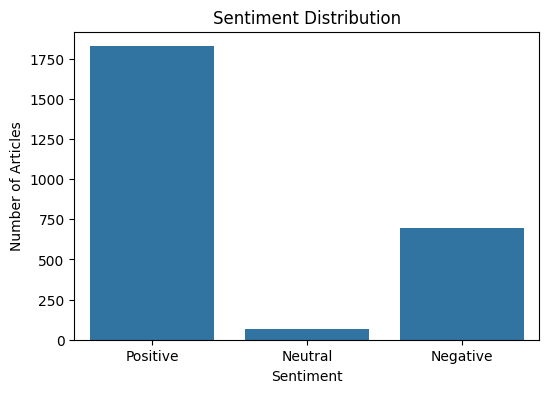

In [52]:
# === Visualization Section ===

# 1. Distribution of Sentiment Labels
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df, order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Articles')
plt.show()

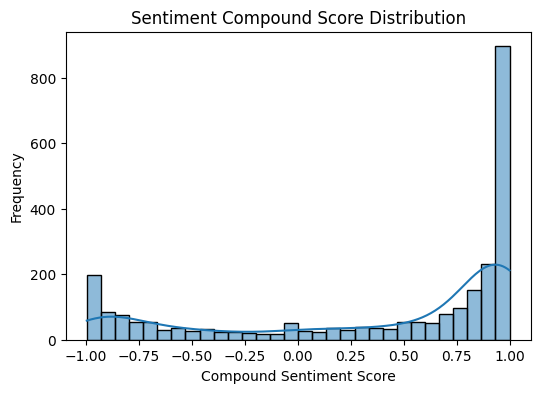

In [53]:
# 2. Histogram of Sentiment Scores (Compound)
plt.figure(figsize=(6,4))
sns.histplot(df['sent_compound'], bins=30, kde=True)
plt.title('Sentiment Compound Score Distribution')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.show()

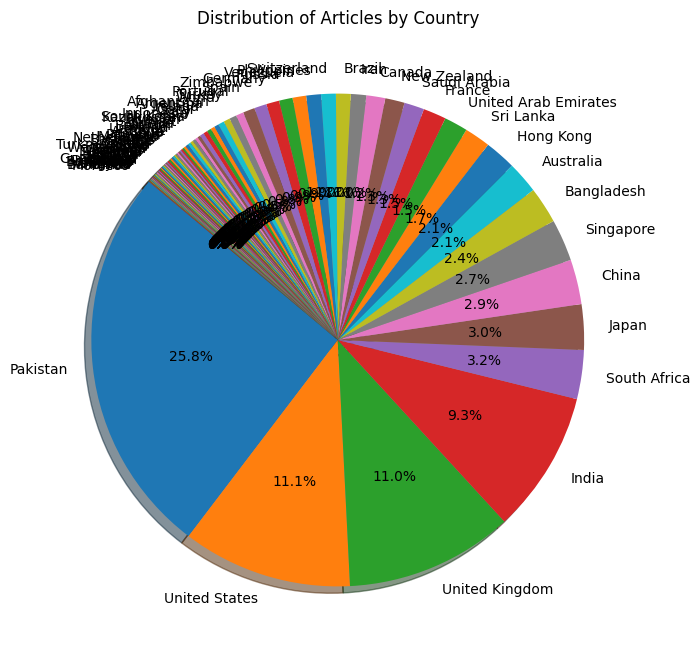

In [54]:
# ====================================
# 🥧 2. Create the pie chart
# ====================================
location_counts = df['Country'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
location_counts.plot.pie(
    autopct='%1.1f%%',      # Show percentage on slices
    startangle=140,         # Start angle of the pie chart for aesthetics
    shadow=True             # Optional shadow effect
)
plt.ylabel('')              # Hide the default y-label
plt.title('Distribution of Articles by Country')
plt.show()

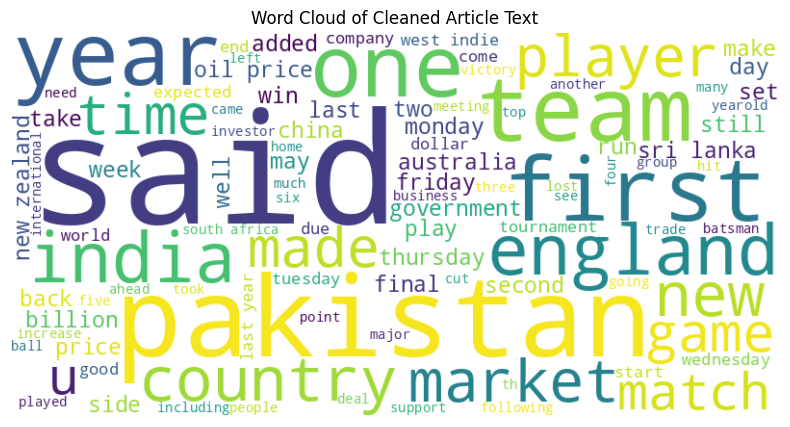

In [55]:
# 4. Word Cloud of Most Frequent Words in Cleaned Articles
text_concat = ' '.join(df['cleaned_article'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text_concat)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Article Text')
plt.show()


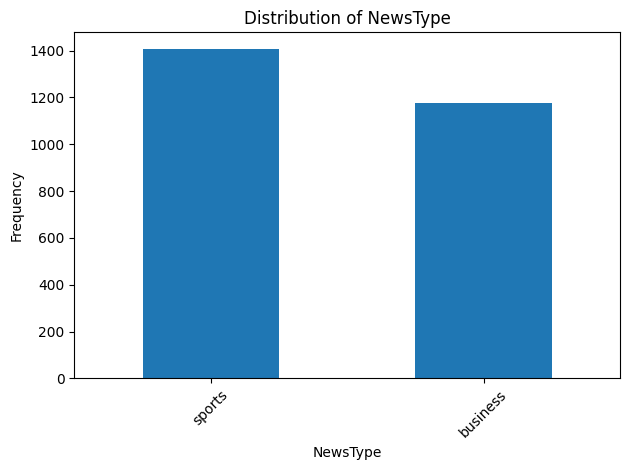

In [56]:
# Calculate frequency counts of each NewsType category
news_type_counts = df['NewsType'].value_counts()

# Plot a bar chart of NewsType distribution
news_type_counts.plot.bar(title='Distribution of NewsType')

# Add labels to the plot for clarity
plt.xlabel('NewsType')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Rotate x-axis labels if they overlap

# Display the plot
plt.tight_layout()  # Adjust layout to fit labels
plt.show()


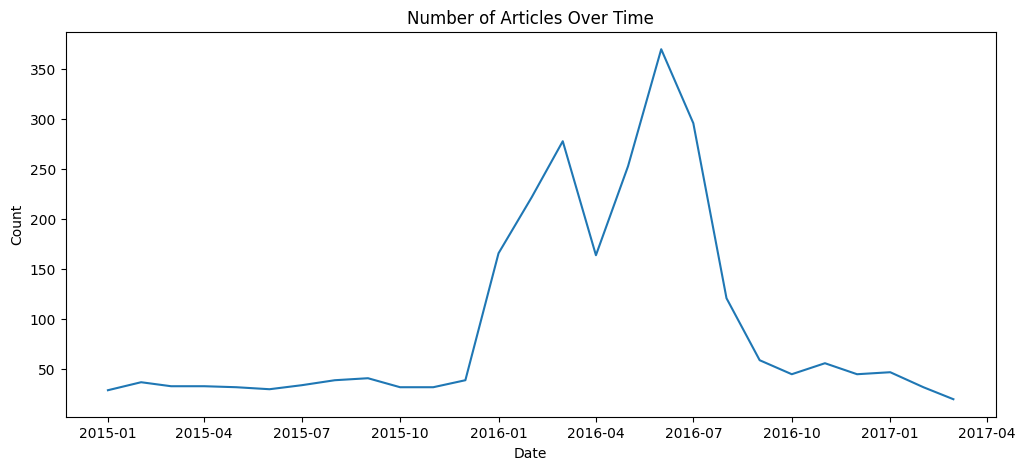

In [57]:
# 6. Time Series: Number of Articles Over Time (Monthly)
df['month_year'] = df['Date'].dt.to_period('M')
monthly_counts = df.groupby('month_year').size()
monthly_counts.index = monthly_counts.index.to_timestamp()

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values)
plt.title('Number of Articles Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()


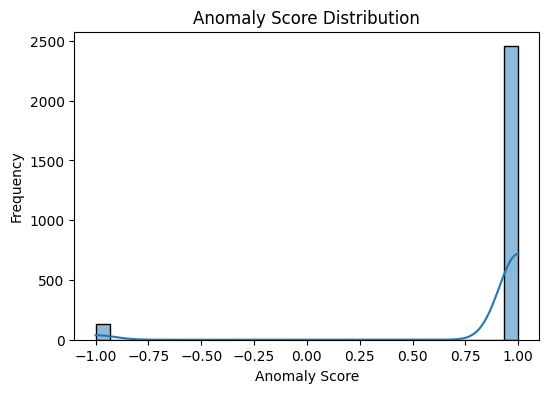

In [58]:
# 7. Anomaly Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['anomaly_score'], bins=30, kde=True)
plt.title('Anomaly Score Distribution')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.show()

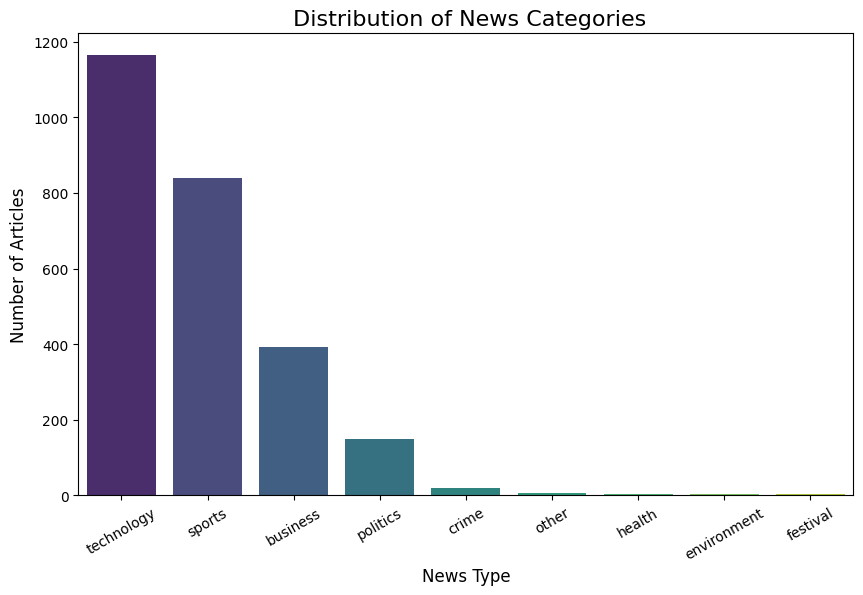

In [59]:

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='News_Category', order=df['News_Category'].value_counts().index, palette='viridis')
plt.title(' Distribution of News Categories', fontsize=16)
plt.xlabel('News Type', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(rotation=30)
plt.show()

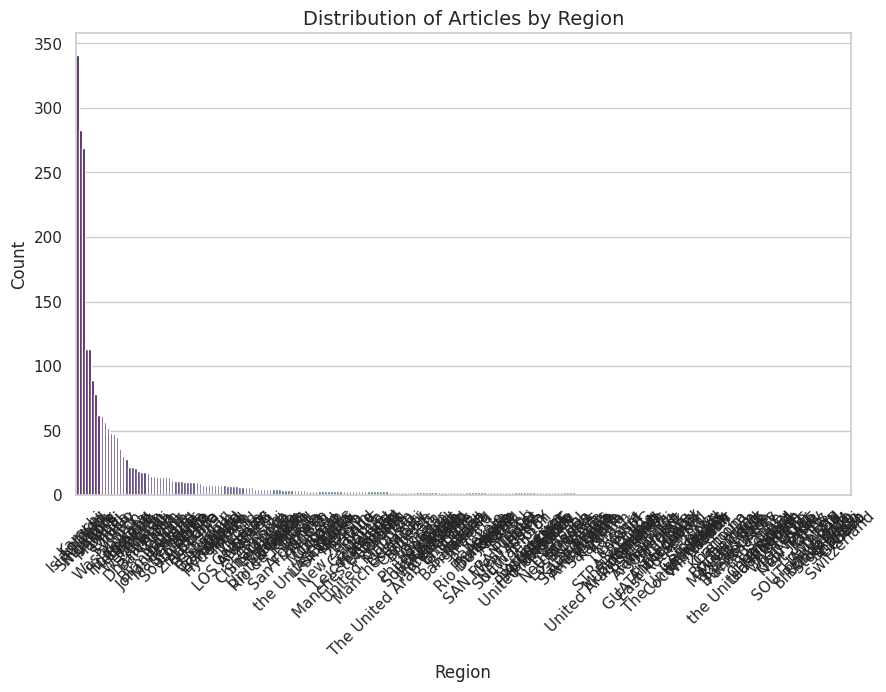

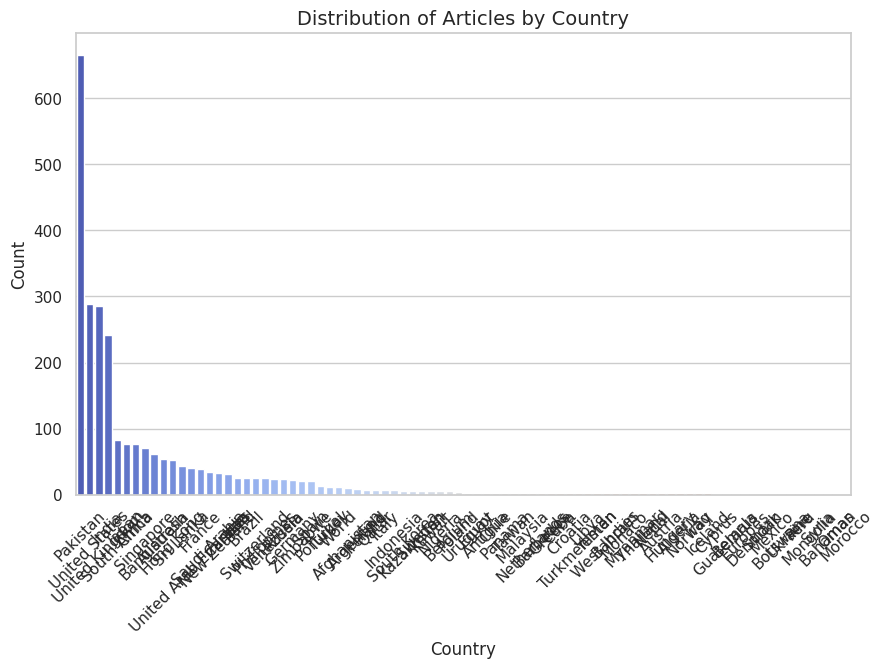

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set(style="whitegrid")

# --- Bar plot for Region ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Region', palette='viridis', order=df['Region'].value_counts().index)
plt.title('Distribution of Articles by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# --- Bar plot for Country ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Country', palette='coolwarm', order=df['Country'].value_counts().index)
plt.title('Distribution of Articles by Country', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


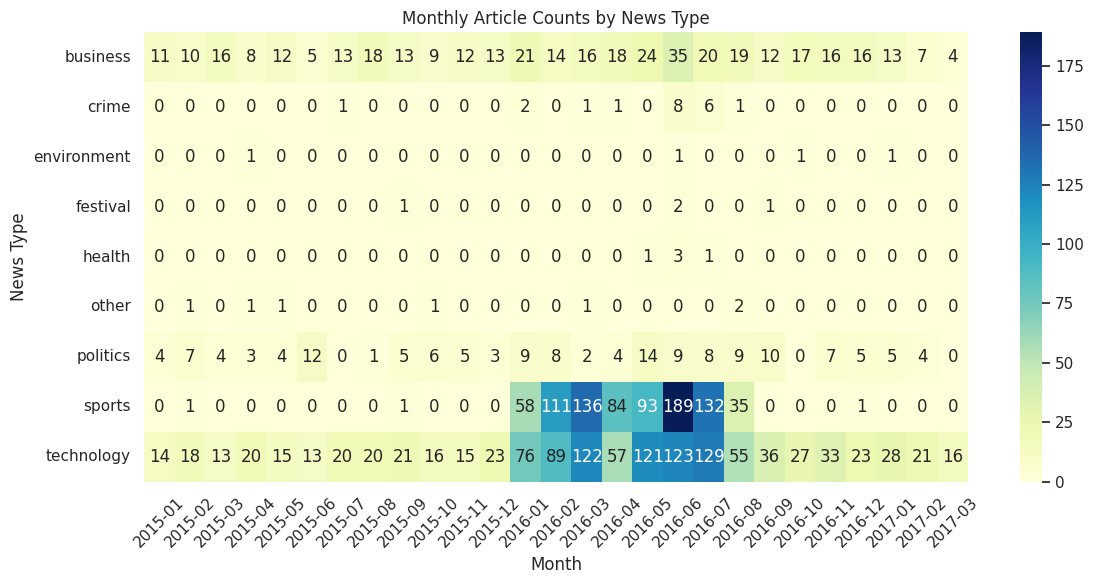

In [61]:


# Assuming df has 'NewsType_final' and 'Date' columns and 'Date' is datetime
df['month'] = df['Date'].dt.to_period('M').astype(str)

# Create a pivot table counting number of articles per NewsType per month
pivot_table = df.pivot_table(
    index='News_Category',
    columns='month',
    values='Article',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Monthly Article Counts by News Type')
plt.xlabel('Month')
plt.ylabel('News Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


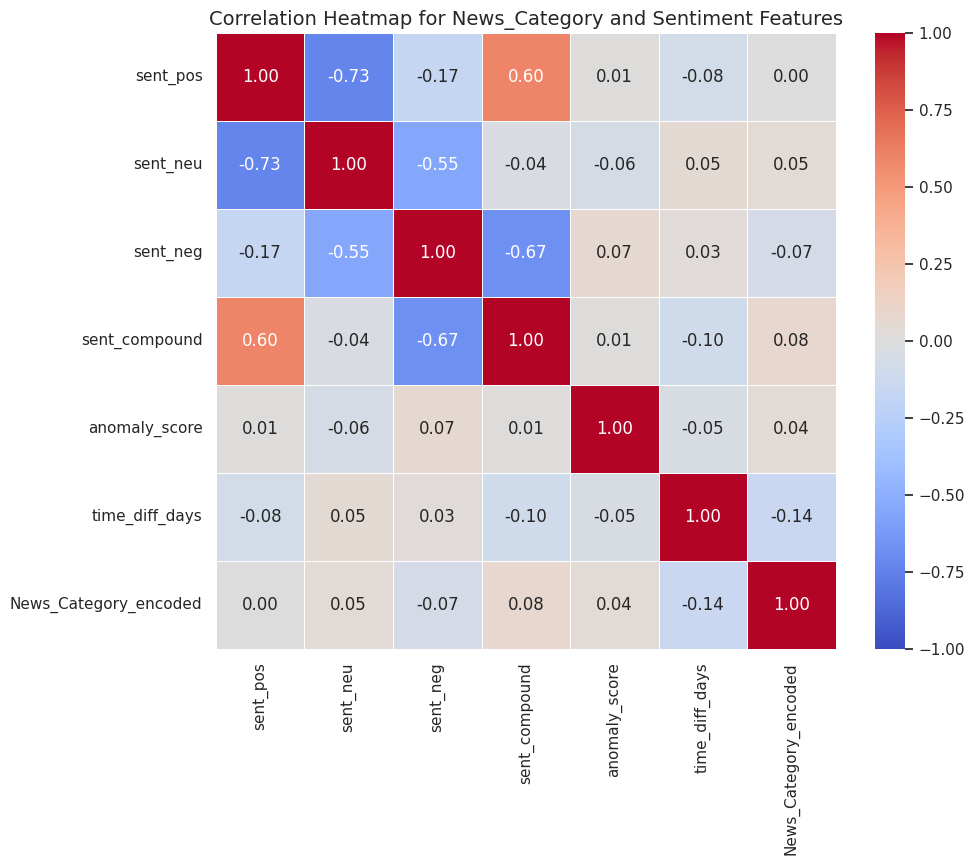

In [62]:


# Encode 'News_Category' as categorical codes if it's not numeric already
df['News_Category_encoded'] = df['News_Category'].astype('category').cat.codes

# Select the columns of interest for correlation (e.g., numeric columns)
numeric_cols = ['sent_pos', 'sent_neu', 'sent_neg', 'sent_compound', 'anomaly_score', 'time_diff_days', 'News_Category_encoded']

# Compute the correlation matrix for these columns
correlation_matrix = df[numeric_cols].corr()

# Generate a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)

# Add title
plt.title('Correlation Heatmap for News_Category and Sentiment Features', fontsize=14)

# Show the plot
plt.show()


In [63]:
#df=pd.read_csv('/content/processed_features.csv')
df.columns



Index(['Article', 'Date', 'Heading', 'NewsType', 'raw_article',
       'cleaned_article', 'cleaned_heading', 'Sentiment', 'Region', 'Country',
       'sent_pos', 'sent_neu', 'sent_neg', 'sent_compound', 'year', 'month',
       'day_of_week', 'time_diff_days', 'topic', 'text_embedding',
       'heading_embedding', 'anomaly_score', 'anomaly', 'News_Category',
       'month_year', 'News_Category_encoded'],
      dtype='object')

In [64]:

# (Optional) Check if the renaming worked
print(df.columns)

df.dtypes

Index(['Article', 'Date', 'Heading', 'NewsType', 'raw_article',
       'cleaned_article', 'cleaned_heading', 'Sentiment', 'Region', 'Country',
       'sent_pos', 'sent_neu', 'sent_neg', 'sent_compound', 'year', 'month',
       'day_of_week', 'time_diff_days', 'topic', 'text_embedding',
       'heading_embedding', 'anomaly_score', 'anomaly', 'News_Category',
       'month_year', 'News_Category_encoded'],
      dtype='object')


,0
Article,object
Date,datetime64[ns]
Heading,object
NewsType,object
raw_article,object
cleaned_article,object
cleaned_heading,object
Sentiment,object
Region,object
Country,object


In [65]:
df.shape

(2585, 26)

##🤖⚙️MODELING

###1. 🛡️🔍 Linguistic Anomaly Detection Model

Preprocess

In [66]:


print("Starting anomaly model training...")

# ---------------------
# LOAD DATA
# ---------------------
data = df   # if already loaded in memory
print("Dataset loaded.")

# ---------------------
# BUILD FEATURE SET
# ---------------------
print("Building feature matrix...")

# Step 1: select numeric + categorical
features = data[['sent_pos', 'sent_neu', 'sent_neg', 'sent_compound',
                 'time_diff_days', 'Region', 'Country']]

# Step 2: one-hot encode categorical features
features = pd.get_dummies(features, columns=['Region', 'Country'], drop_first=True)

# Step 3: add embeddings
embedding_df = pd.DataFrame(data['text_embedding'].tolist())
features = pd.concat([features, embedding_df], axis=1)

print("Feature matrix built. Shape:", features.shape)



Starting anomaly model training...
Dataset loaded.
Building feature matrix...
Feature matrix built. Shape: (2585, 1108)


Scaling

In [67]:
# ---------------------
# SELECT ONLY NUMERICAL COLUMNS
# ---------------------
numeric_features = features.select_dtypes(include=['float64','float32','int64','int32'])

# Ensure all column names are strings (this fixes the TypeError)
numeric_features.columns = numeric_features.columns.astype(str)

print("Numeric feature count:", numeric_features.shape[1])

# ---------------------
# SCALE FEATURES
# ---------------------
print("Scaling features...")
scaler = StandardScaler()
features_scaled = scaler.fit_transform(numeric_features)
print("Scaling done.")


Numeric feature count: 773
Scaling features...
Scaling done.


Model Traning

In [68]:

# ---------------------
# TRAIN MODEL
# ---------------------
print("Training Isolation Forest...")
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(features_scaled)
print("Model trained.")

# ---------------------
# SAVE MODEL + SCALER
# ---------------------
joblib.dump(model, "isolation_forest_model.pkl")
joblib.dump(scaler, "scaler_isolation_forest.pkl")

print("Model and scaler saved successfully.")


Training Isolation Forest...
Model trained.
Model and scaler saved successfully.


###2. 🤖📡 Source Discrepancy Detection


In [69]:
# Look at the first few rows of the 'text_embedding' column
print(data['text_embedding'].head())


0    [-0.08340474, -0.17146313, 0.1805476, 0.040498...
1    [-0.22197506, 0.10724135, 0.34658808, -0.05955...
2    [-0.005767609, -0.1300852, 0.39958104, -0.0504...
3    [-0.28628477, 0.030252095, 0.38234857, 0.02368...
4    [-0.2920597, 0.05616387, 0.4698508, -0.0155470...
Name: text_embedding, dtype: object


In [70]:


# If your embeddings are currently strings that look like '[0.1 0.2 -0.3 ...]', parse them:
def parse_embedding(s):
    if isinstance(s, str):
        s = s.strip('[]')
        return np.fromstring(s, sep=' ')
    return s

data['text_embedding'] = data['text_embedding'].apply(parse_embedding)

# Filter rare classes before building features, preserve consistent indices
class_counts = data['Country'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
filtered_data = data[data['Country'].isin(valid_classes)].reset_index(drop=True)
print("Loaded filtered_data ")
# Step 2: Expand embeddings into separate columns & ensure numeric dtype
text_emb_df = pd.DataFrame(filtered_data['text_embedding'].tolist()).astype(float)
text_emb_df.columns = [f"text_emb_{i}" for i in range(text_emb_df.shape[1])]

print("Embedded done")

# Step 3: Combine embeddings with other numerical features
features = pd.concat([
    filtered_data[['sent_pos', 'sent_neu', 'sent_neg', 'sent_compound', 'topic']].reset_index(drop=True),
    text_emb_df.reset_index(drop=True)
], axis=1)
print("feature selected")

# Step 4: Encode labels
le = LabelEncoder()
y = le.fit_transform(filtered_data['Country'])

# Validate consistent sample counts
assert features.shape[0] == len(y), "Features and labels length mismatch!"

print('Encoding completed')

# Step 5: Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=42, stratify=y
)

print('train and test split completed')

# Step 6: Initialize and train XGBoost multiclass classifier
num_classes = len(le.classes_)
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Model Accuracy: {accuracy*100:.2f}%")

print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(num_classes),
    target_names=le.classes_,
    zero_division=0
))


Loaded filtered_data 
Embedded done
feature selected
Encoding completed
train and test split completed
XGBoost Model Accuracy: 56.42%
                      precision    recall  f1-score   support

         Afghanistan       0.00      0.00      0.00         2
             Algeria       0.00      0.00      0.00         0
             Antigua       0.00      0.00      0.00         1
           Argentina       0.50      0.50      0.50         2
           Australia       0.57      0.36      0.44        11
             Austria       0.00      0.00      0.00         0
             Bahrain       0.00      0.00      0.00         0
          Bangladesh       0.22      0.17      0.19        12
            Barbados       0.00      0.00      0.00         1
             Belgium       0.00      0.00      0.00         1
              Brazil       0.67      0.40      0.50         5
              Canada       0.00      0.00      0.00         6
               Chile       0.00      0.00      0.00        

In [71]:


# After training your XGBoost model (assume variable 'model')
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as xgboost_model.pkl")


Model saved as xgboost_model.pkl



###3. ⏱️🔍 Temporal Anomaly Detection


In [72]:
data['Date'] = pd.to_datetime(data['Date'])


In [73]:
agg_sentiment = (
    data.groupby(['Region', 'Date'])
        .agg(sent_compound_mean=('sent_compound', 'mean'))
        .reset_index()
)


In [74]:
agg_sentiment = agg_sentiment.dropna(subset=['sent_compound_mean'])


In [75]:
import statsmodels.api as sm
import numpy as np

anomaly_results_arima = []

for region in agg_sentiment['Region'].unique():
    region_df = agg_sentiment[agg_sentiment['Region'] == region].copy()
    region_df.set_index('Date', inplace=True)
    region_df = region_df.asfreq('D')
    y = region_df['sent_compound_mean'].fillna(method='ffill')

    if len(y) < 5:
        continue  # skip small series

    try:
        model = sm.tsa.ARIMA(y, order=(1,1,1))
        model_fit = model.fit()

        # Forecast in-sample
        forecast = model_fit.fittedvalues

        # Residuals
        residuals = y - forecast

        # Detect anomalies
        region_df['anomaly'] = np.abs(residuals) > 2 * residuals.std()
        anomaly_results_arima.append(region_df.reset_index())

    except Exception as e:
        print(f"ARIMA failed for region {region}: {e}")

anomaly_arima_df = pd.concat(anomaly_results_arima)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [76]:
import pickle
import statsmodels.api as sm

# Example: Fit ARIMA model
# y = your time series data
model = sm.tsa.ARIMA(y, order=(1,1,1))
model_fit = model.fit()

# Save model
with open('arima_model.pkl', 'wb') as pkl_file:
    pickle.dump(model_fit, pkl_file)

print("ARIMA model saved successfully!")


ARIMA model saved successfully!


In [81]:
import pandas as pd
from prophet import Prophet
from prophet.serialize import model_to_json
import json
import os

# Copy your data
df = data.copy()

# Ensure 'Date' is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate daily sentiment per Country
agg_sentiment = df.groupby(['Country', 'Date']).agg(
    daily_sentiment=('sent_compound', 'mean')
).reset_index()

# Folder to save models
model_dir = 'prophet_models'
os.makedirs(model_dir, exist_ok=True)

# Dictionary to store anomalies per Country
anomaly_results = {}

# Train Prophet model per Country
Countrys = agg_sentiment['Country'].unique()
for Country in Countrys:
    Country_df = agg_sentiment[agg_sentiment['Country'] == Country].copy()
    Country_df.rename(columns={'Date': 'ds', 'daily_sentiment': 'y'}, inplace=True)

    # Skip Countrys with too few data points
    if len(Country_df) < 2:
        continue

    # Fit Prophet
    model = Prophet(daily_seasonality=True)
    model.fit(Country_df)

    # Save model to disk as JSON
    model_path = os.path.join(model_dir, f'prophet_model_{Country}.json')
    with open(model_path, 'w') as fout:
        json.dump(model_to_json(model), fout)

    # Predict on historical data
    future = model.make_future_dataframe(periods=0)
    forecast = model.predict(future)

    # Residuals and anomaly detection
    Country_df['residual'] = Country_df['y'] - forecast['yhat']
    std_resid = Country_df['residual'].std()
    Country_df['anomaly'] = Country_df['residual'].abs() > 2 * std_resid

    # Store results
    anomaly_results[Country] = Country_df

print("Prophet models saved and anomalies detected for each Country!")


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 5.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 0.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to overr

Prophet models saved and anomalies detected for each Country!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [78]:
# ===  Save for further modeling or dashboarding ===
df.to_csv('processed_features_Out.csv', index=False)

In [79]:
data.shape

(2585, 26)

In [80]:
data.columns

Index(['Article', 'Date', 'Heading', 'NewsType', 'raw_article',
       'cleaned_article', 'cleaned_heading', 'Sentiment', 'Region', 'Country',
       'sent_pos', 'sent_neu', 'sent_neg', 'sent_compound', 'year', 'month',
       'day_of_week', 'time_diff_days', 'topic', 'text_embedding',
       'heading_embedding', 'anomaly_score', 'anomaly', 'News_Category',
       'month_year', 'News_Category_encoded'],
      dtype='object')